# Online Koopman Adaptation Under Topology Shock

Traffic and power networks drift over time: **lane blockages**, lost transmission
lines, and rewired contact patterns change the graph itself — not just local
dynamics. Retraining the full GNN+Koopman pipeline after every structural change
is expensive and slow.

**Recursive Koopman Learning** updates only the linear operator `K` from
streaming encoded snapshots while keeping the encoder/decoder frozen. This
notebook simulates a **corridor blockage** on a small **grid sensor network**:
mid-sequence, horizontal links along one row are removed so diffusion can no
longer mix across that barrier (a traffic-like topology shock).

We use ``allow_dynamic_topology=True`` so each snapshot carries its own
``edge_index``; ``adapt_step`` encodes with the snapshot-appropriate graph.

**What RLS can and cannot fix.** RLS targets latent consistency
``encode(x_{t+1}) ≈ encode(x_t) K^⊤``. The encoder/decoder were trained on the
**pre-blockage** graph, so message-passing neighborhoods change after rewiring
and some residual physical bias is expected even after `K` adapts.


## The offline fit → online adapt workflow

Each stage uses the standard KoopmanGraph pipeline, with adaptation restricted
to the operator:

1. **Encode (lifting):** A GNN encoder maps node features into latent states
   `z_t` while respecting graph topology.
2. **Offline `fit`:** Train encoder, decoder, and dense `K` on pre-shock data
   (full grid, static topology).
3. **`enable_online_adaptation()`:** Freeze encoder/decoder; initialize RLS on `K`.
4. **`adapt_step`:** For each new pair `(x_t, x_{t+1})`, encode both snapshots
   (each with its own `edge_index`) and update `K` without GNN backprop.
5. **Evaluate:** Score stale vs. adapted models on a held-out post-shock tail.

See also [`06_epidemic_ring.ipynb`](06_epidemic_ring.ipynb) for training on
periodically rewired contact graphs, and
[`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb) for
operator stability under long rollouts.


In [1]:
import copy
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor
from torch_geometric.data import Data
from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

torch.manual_seed(0)
np.random.seed(0)

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, LossWeights
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets.dynamics import (
    add_gaussian_noise,
    apply_laplacian_diffusion_step,
    initial_node_features,
    make_generator,
    normalized_step_operator,
)
from koopman_graph.datasets.grid import grid_node_index


## Build pre-shock and post-shock grid sequences

We simulate Laplacian diffusion on a 4-connected **grid** of sensors. Before the
shock, the graph is a full lattice. At ``shock_time``, **horizontal edges along
one row are removed**, modelling a blocked corridor. Dynamics continue on the
reduced graph with the same diffusion parameters — only topology changes.

The combined timeline is stored with ``allow_dynamic_topology=True``. We split it
into a **pre-shock** segment (offline training, static full grid) and a
**post-shock** tail (online adaptation on the blocked graph).


In [2]:
IN_CHANNELS = 1
SEED = 7
BLOCKED_ROW = 2

if os.environ.get("PYTEST_CURRENT_TEST"):
    NUM_ROWS, NUM_COLS = 4, 4
    NUM_TIMESTEPS = 45
    SHOCK_TIME = 14
    ADAPT_STEPS = 14
    FIT_EPOCHS = 50
else:
    NUM_ROWS, NUM_COLS = 5, 5
    NUM_TIMESTEPS = 55
    SHOCK_TIME = 22
    ADAPT_STEPS = 25
    FIT_EPOCHS = 80

DIFFUSION_RATE = 0.45
DECAY_RATE = 0.98
NOISE_STD = 0.01


def grid_edge_index(num_rows: int, num_cols: int) -> Tensor:
    """Bidirectional edges for a 4-connected grid."""
    if num_rows < 1 or num_cols < 1:
        return torch.zeros((2, 0), dtype=torch.long)
    src: list[int] = []
    dst: list[int] = []
    for row in range(num_rows):
        for col in range(num_cols):
            node = grid_node_index(row, col, num_cols=num_cols)
            if col < num_cols - 1:
                neighbor = grid_node_index(row, col + 1, num_cols=num_cols)
                src.extend([node, neighbor])
                dst.extend([neighbor, node])
            if row < num_rows - 1:
                neighbor = grid_node_index(row + 1, col, num_cols=num_cols)
                src.extend([node, neighbor])
                dst.extend([neighbor, node])
    return torch.tensor([src, dst], dtype=torch.long)


def grid_edge_index_with_row_blockage(
    num_rows: int,
    num_cols: int,
    blocked_row: int,
) -> Tensor:
    """Full grid minus horizontal links on ``blocked_row`` (lane blockage)."""
    if num_rows < 1 or num_cols < 1:
        return torch.zeros((2, 0), dtype=torch.long)
    src: list[int] = []
    dst: list[int] = []
    for row in range(num_rows):
        for col in range(num_cols):
            node = grid_node_index(row, col, num_cols=num_cols)
            if col < num_cols - 1 and row != blocked_row:
                neighbor = grid_node_index(row, col + 1, num_cols=num_cols)
                src.extend([node, neighbor])
                dst.extend([neighbor, node])
            if row < num_rows - 1:
                neighbor = grid_node_index(row + 1, col, num_cols=num_cols)
                src.extend([node, neighbor])
                dst.extend([neighbor, node])
    return torch.tensor([src, dst], dtype=torch.long)


def simulate_grid_blockage_sequence(
    *,
    num_rows: int,
    num_cols: int,
    num_timesteps: int,
    shock_time: int,
    blocked_row: int,
    in_channels: int,
    diffusion_rate: float,
    decay_rate: float,
    noise_std: float,
    seed: int,
) -> tuple[GraphSnapshotSequence, GraphSnapshotSequence, GraphSnapshotSequence]:
    """Return pre-shock, post-shock, and full dynamic sequences."""
    num_nodes = num_rows * num_cols
    full_edges = grid_edge_index(num_rows, num_cols)
    blocked_edges = grid_edge_index_with_row_blockage(num_rows, num_cols, blocked_row)
    generator = make_generator(seed)
    dtype = torch.float32
    state = initial_node_features(
        num_nodes,
        in_channels,
        "random",
        generator=generator,
        dtype=dtype,
    )

    snapshots: list[Data] = []
    for timestep in range(num_timesteps):
        edges = full_edges if timestep < shock_time else blocked_edges
        snapshots.append(Data(x=state.clone(), edge_index=edges))
        if timestep == num_timesteps - 1:
            break
        step_op = normalized_step_operator(
            edges,
            num_nodes,
            diffusion_rate,
            dtype=dtype,
        )
        state = apply_laplacian_diffusion_step(state, step_op, decay_rate)
        state = add_gaussian_noise(state, noise_std, generator=generator, dtype=dtype)

    full_sequence = GraphSnapshotSequence(snapshots, allow_dynamic_topology=True)
    pre_shock = full_sequence.slice(0, shock_time)
    post_shock = full_sequence.slice(shock_time, len(full_sequence))
    return pre_shock, post_shock, full_sequence


pre_shock, post_shock, full_sequence = simulate_grid_blockage_sequence(
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    num_timesteps=NUM_TIMESTEPS,
    shock_time=SHOCK_TIME,
    blocked_row=BLOCKED_ROW,
    in_channels=IN_CHANNELS,
    diffusion_rate=DIFFUSION_RATE,
    decay_rate=DECAY_RATE,
    noise_std=NOISE_STD,
    seed=SEED,
)

full_edges = grid_edge_index(NUM_ROWS, NUM_COLS)
blocked_edges = grid_edge_index_with_row_blockage(NUM_ROWS, NUM_COLS, BLOCKED_ROW)

print(f"Grid: {NUM_ROWS}x{NUM_COLS} ({NUM_ROWS * NUM_COLS} sensors)")
print(f"Shock at timestep {SHOCK_TIME}: remove horizontal edges on row {BLOCKED_ROW}")
print(f"Edges full grid: {full_edges.shape[1]}  blocked: {blocked_edges.shape[1]}")
print(f"Dynamic topology: {full_sequence.is_dynamic_topology}")
print(f"Pre-shock snapshots:  {len(pre_shock)}")
print(f"Post-shock snapshots: {len(post_shock)}")


Grid: 5x5 (25 sensors)
Shock at timestep 22: remove horizontal edges on row 2
Edges full grid: 80  blocked: 72
Dynamic topology: True
Pre-shock snapshots:  22
Post-shock snapshots: 33


## Visualize the topology shock

The left panel shows the **full timeline** with a vertical marker at the shock.
By shock time the field is already well-mixed, so the raw features barely change
at the marker — the blockage is a **subtle** effect on this color scale, not a
visible discontinuity. (Comparing pre-/post-shock slices with different time
origins would exaggerate this into an artificial "flattening".)

To make the topology effect visible, the right panel plots the **counterfactual
difference**: from the shock-time state, roll the noise-free diffusion forward
on the *blocked* grid and on the *full* grid, and show `blocked − full`. The
difference is concentrated on the blocked row and its neighbors — this is the
signal the stale model mis-tracks.


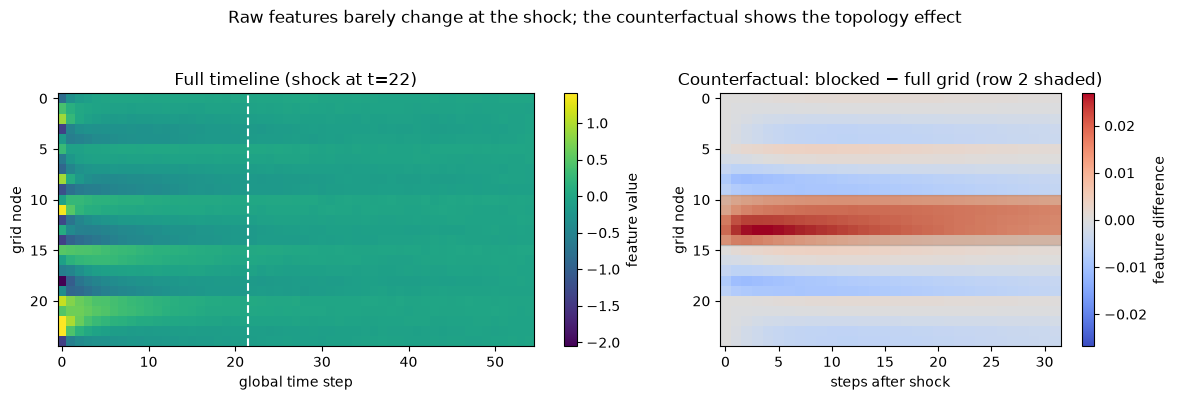

Node std just before / after shock: 0.0765 → 0.0749 (no visible discontinuity in raw features)
Counterfactual divergence ||blocked - full|| / ||signal||: +1 step: 0.057, +5: 0.102, +32: 0.110


In [3]:
def sequence_matrix(sequence) -> np.ndarray:
    """Return node features as (num_nodes, num_timesteps)."""
    return torch.stack([snapshot.x[:, 0] for snapshot in sequence], dim=1).numpy()


full_matrix = sequence_matrix(full_sequence)
num_nodes = NUM_ROWS * NUM_COLS

# Counterfactual: noise-free rollouts from the shock-time state on both graphs.
op_blocked = normalized_step_operator(blocked_edges, num_nodes, DIFFUSION_RATE, dtype=torch.float32)
op_full = normalized_step_operator(full_edges, num_nodes, DIFFUSION_RATE, dtype=torch.float32)
state_blocked = full_sequence[SHOCK_TIME].x.clone()
state_full = state_blocked.clone()
divergence: list[Tensor] = []
for _ in range(len(post_shock) - 1):
    state_blocked = apply_laplacian_diffusion_step(state_blocked, op_blocked, DECAY_RATE)
    state_full = apply_laplacian_diffusion_step(state_full, op_full, DECAY_RATE)
    divergence.append((state_blocked - state_full)[:, 0].clone())
diff_matrix = torch.stack(divergence, dim=1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.4, 1.0]})

im0 = axes[0].imshow(full_matrix, aspect="auto", cmap="viridis")
axes[0].axvline(SHOCK_TIME - 0.5, color="white", linewidth=1.5, linestyle="--")
axes[0].set_title(f"Full timeline (shock at t={SHOCK_TIME})")
axes[0].set_xlabel("global time step")
axes[0].set_ylabel("grid node")
fig.colorbar(im0, ax=axes[0], label="feature value")

diff_scale = float(np.abs(diff_matrix).max())
im1 = axes[1].imshow(
    diff_matrix, aspect="auto", cmap="coolwarm", vmin=-diff_scale, vmax=diff_scale
)
row_start = BLOCKED_ROW * NUM_COLS
axes[1].axhspan(row_start - 0.5, row_start + NUM_COLS - 0.5, color="black", alpha=0.12)
axes[1].set_title(f"Counterfactual: blocked − full grid (row {BLOCKED_ROW} shaded)")
axes[1].set_xlabel("steps after shock")
axes[1].set_ylabel("grid node")
fig.colorbar(im1, ax=axes[1], label="feature difference")

fig.suptitle("Raw features barely change at the shock; the counterfactual shows the topology effect", y=1.04)
fig.tight_layout()
plt.show()

signal_norm = np.linalg.norm(full_matrix[:, SHOCK_TIME + 1 :], axis=0)
diff_norm = np.linalg.norm(diff_matrix, axis=0)
print(
    f"Node std just before / after shock: "
    f"{full_matrix[:, SHOCK_TIME - 1].std():.4f} → {full_matrix[:, SHOCK_TIME].std():.4f} "
    "(no visible discontinuity in raw features)"
)
print(
    f"Counterfactual divergence ||blocked - full|| / ||signal||: "
    f"+1 step: {diff_norm[0] / signal_norm[0]:.3f}, "
    f"+5: {diff_norm[4] / signal_norm[4]:.3f}, "
    f"+{len(diff_norm)}: {diff_norm[-1] / signal_norm[-1]:.3f}"
)


## Offline training (pre-shock only)

Train a dense `GraphKoopmanModel` on the nominal full-grid segment. The
encoder/decoder and initial `K` will remain fixed during later online adaptation.


In [4]:
LATENT_DIM = 16
HIDDEN = 32

encoder = GNNEncoder(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN,
    latent_dim=LATENT_DIM,
    num_layers=2,
)
decoder = GNNDecoder(
    latent_dim=LATENT_DIM,
    hidden_channels=HIDDEN,
    out_channels=IN_CHANNELS,
    num_layers=2,
)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=LATENT_DIM,
    time_step=1.0,
    koopman_parameterization="dense",
)

history = model.fit(
    pre_shock,
    epochs=FIT_EPOCHS,
    lr=3e-3,
    loss_weights=LossWeights(
        reconstruction=1.0,
        forward=0.2,
    ),
)
print(f"Final train loss: {history.loss[-1]:.5f}")


Final train loss: 0.00960


## Online adaptation and evaluation protocol

We clone the offline model twice:

- **Stale baseline:** frozen weights from pre-shock training (full grid).
- **Adapted model:** `enable_online_adaptation()` then `adapt_step` on post-shock
  transitions, each encoded with the **blocked** `edge_index` carried by the
  snapshot.

Both models are scored on the **held-out** tail after the adaptation window.

**RLS settings:** forgetting factor `λ = 0.99`, covariance regularization `10³`.

**Metrics:** relative physical error, latent consistency (the RLS objective), and
one-step RMSE. Expect latent consistency to improve; physical error may stay flat
or worsen because the frozen encoder was trained on the full grid.


In [5]:
EVAL_START = ADAPT_STEPS


def relative_one_step_errors(eval_model: GraphKoopmanModel, sequence) -> list[float]:
    """Per-transition relative one-step error ||pred - true|| / ||true||."""
    errors: list[float] = []
    with torch.no_grad():
        for index in range(len(sequence) - 1):
            prediction = eval_model(sequence[index])
            target = sequence[index + 1].x
            denom = torch.linalg.norm(target).clamp_min(1e-8)
            errors.append((torch.linalg.norm(prediction - target) / denom).item())
    return errors


def mean_abs_rmse(eval_model: GraphKoopmanModel, sequence) -> float:
    """Mean absolute one-step RMSE."""
    errors: list[float] = []
    with torch.no_grad():
        for index in range(len(sequence) - 1):
            prediction = eval_model(sequence[index])
            target = sequence[index + 1].x
            errors.append(torch.sqrt(torch.mean((prediction - target) ** 2)).item())
    return float(np.mean(errors))


def latent_consistency_errors(eval_model: GraphKoopmanModel, sequence) -> list[float]:
    """Relative latent residual ||z_{t+1} - z_t K^T|| / ||z_{t+1}||."""
    errors: list[float] = []
    with torch.no_grad():
        for index in range(len(sequence) - 1):
            z_t = eval_model.encode_latent(sequence[index])
            z_tp1 = eval_model.encode_latent(sequence[index + 1])
            pred = z_t @ eval_model.koopman.K.T
            denom = torch.linalg.norm(z_tp1).clamp_min(1e-8)
            errors.append((torch.linalg.norm(z_tp1 - pred) / denom).item())
    return errors


stale_model = copy.deepcopy(model)
stale_model.eval()

adapted_model = copy.deepcopy(model)
adapted_model.enable_online_adaptation(forgetting_factor=0.99, regularization=1e3)
adapted_model.eval()

adapt_errors_stale: list[float] = []
adapt_errors_online: list[float] = []
operator_changes: list[float] = []
for index in range(ADAPT_STEPS):
    adapt_errors_stale.append(
        relative_one_step_errors(stale_model, post_shock.slice(index, index + 2))[0]
    )
    adapt_errors_online.append(
        relative_one_step_errors(adapted_model, post_shock.slice(index, index + 2))[0]
    )
    step = adapted_model.adapt_step(post_shock[index], post_shock[index + 1])
    operator_changes.append(float(step.operator_change_norm.item()))

holdout = post_shock.slice(EVAL_START, len(post_shock))
pre_rel = relative_one_step_errors(stale_model, pre_shock)
stale_holdout_rel = relative_one_step_errors(stale_model, holdout)
adapted_holdout_rel = relative_one_step_errors(adapted_model, holdout)
stale_rmse = mean_abs_rmse(stale_model, holdout)
adapted_rmse = mean_abs_rmse(adapted_model, holdout)
stale_latent = latent_consistency_errors(stale_model, holdout)
adapted_latent = latent_consistency_errors(adapted_model, holdout)

print(f"Adaptation window: transitions 0..{ADAPT_STEPS - 1}")
print(f"Holdout window:    transitions {EVAL_START}..{len(post_shock) - 2}")
print(f"Stale relative physical error (holdout):   {np.mean(stale_holdout_rel):.4f}")
print(f"Adapted relative physical error (holdout): {np.mean(adapted_holdout_rel):.4f}")
print(f"Stale latent consistency (holdout):        {np.mean(stale_latent):.4f}")
print(f"Adapted latent consistency (holdout):      {np.mean(adapted_latent):.4f}")
print(f"Stale abs RMSE (holdout):                  {stale_rmse:.5f}")
print(f"Adapted abs RMSE (holdout):                {adapted_rmse:.5f}")

# Smoke check: RLS must improve its objective (latent consistency), not
# necessarily physical RMSE under a frozen encoder + topology change.
assert np.mean(adapted_latent) < np.mean(stale_latent), (
    "Adapted latent consistency should beat the stale operator on holdout"
)


Adaptation window: transitions 0..24
Holdout window:    transitions 25..31
Stale relative physical error (holdout):   0.3026
Adapted relative physical error (holdout): 0.3158
Stale latent consistency (holdout):        0.0861
Adapted latent consistency (holdout):      0.0221
Stale abs RMSE (holdout):                  0.01686
Adapted abs RMSE (holdout):                0.01763


## Problem: the offline model goes stale after rewiring

After edges are removed, the frozen operator fitted on the **full grid** mis-tracks
post-shock transitions. Relative one-step physical error rises in the adaptation
window even before we start updating `K`.


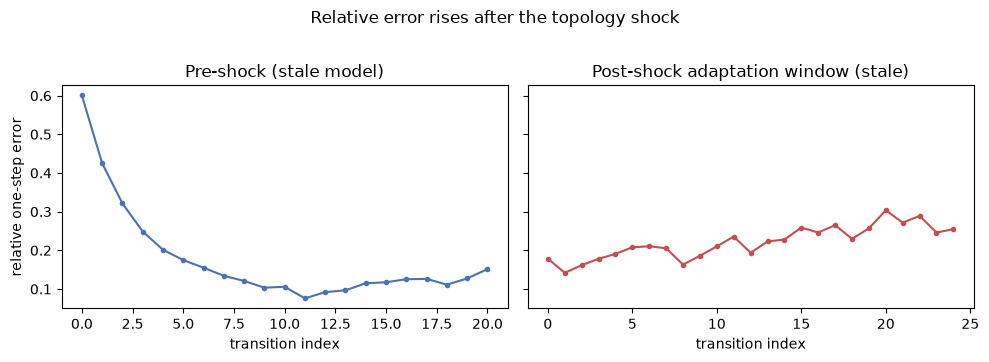

Mean relative error pre-shock (all):                  0.1776
Mean relative error pre-shock (last 10 transitions):  0.1138
Mean relative error post-shock (stale, adapt window): 0.2214


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

axes[0].plot(pre_rel, color="#4c72b0", marker="o", markersize=3)
axes[0].set_title("Pre-shock (stale model)")
axes[0].set_xlabel("transition index")
axes[0].set_ylabel("relative one-step error")

axes[1].plot(adapt_errors_stale, color="#c44e52", marker="o", markersize=3)
axes[1].set_title("Post-shock adaptation window (stale)")
axes[1].set_xlabel("transition index")

fig.suptitle("Relative error rises after the topology shock", y=1.02)
fig.tight_layout()
plt.show()

print(f"Mean relative error pre-shock (all):                  {np.mean(pre_rel):.4f}")
print(f"Mean relative error pre-shock (last 10 transitions):  {np.mean(pre_rel[-10:]):.4f}")
print(f"Mean relative error post-shock (stale, adapt window): {np.mean(adapt_errors_stale):.4f}")


## Solution: RLS updates `K` online on the blocked graph

`adapt_step` encodes each snapshot with its current `edge_index`, then applies an
RLS update to `K`. Latent consistency (the RLS objective) typically improves.
Physical one-step error may stay flat or rise when the frozen GNN encodings are
misaligned with the blocked graph — large ``||ΔK||`` spikes often reflect that
mismatch rather than a successful physical fix.


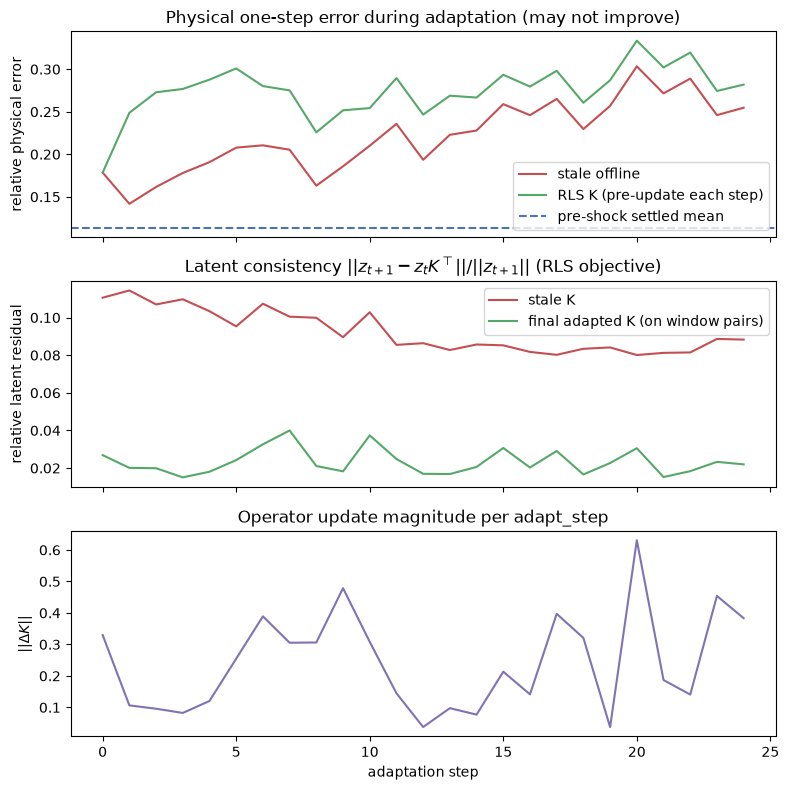

Mean physical error (adapt window) — stale:              0.2214
Mean physical error (adapt window) — RLS pre-update:     0.2742
Mean latent residual on adapt window — stale K:          0.0926
Mean latent residual on adapt window — final adapted K:  0.0233


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
time_idx = np.arange(ADAPT_STEPS)

# Physical errors were measured *before* each adapt_step (progressive K).
axes[0].plot(time_idx, adapt_errors_stale, color="#c44e52", label="stale offline")
axes[0].plot(
    time_idx,
    adapt_errors_online,
    color="#55a868",
    label="RLS K (pre-update each step)",
)
axes[0].axhline(
    np.mean(pre_rel[-10:]),
    color="#4c72b0",
    linestyle="--",
    label="pre-shock settled mean",
)
axes[0].set_ylabel("relative physical error")
axes[0].set_title("Physical one-step error during adaptation (may not improve)")
axes[0].legend()

# Latent residuals use final adapted K vs stale K on the same encoded pairs.
latent_stale_stream: list[float] = []
latent_adapt_stream: list[float] = []
with torch.no_grad():
    for index in range(ADAPT_STEPS):
        z_t = adapted_model.encode_latent(post_shock[index])
        z_tp1 = adapted_model.encode_latent(post_shock[index + 1])
        denom = torch.linalg.norm(z_tp1).clamp_min(1e-8)
        stale_pred = z_t @ stale_model.koopman.K.T
        adapt_pred = z_t @ adapted_model.koopman.K.T
        latent_stale_stream.append((torch.linalg.norm(z_tp1 - stale_pred) / denom).item())
        latent_adapt_stream.append((torch.linalg.norm(z_tp1 - adapt_pred) / denom).item())

axes[1].plot(time_idx, latent_stale_stream, color="#c44e52", label="stale K")
axes[1].plot(
    time_idx,
    latent_adapt_stream,
    color="#55a868",
    label="final adapted K (on window pairs)",
)
axes[1].set_ylabel("relative latent residual")
axes[1].set_title(r"Latent consistency $||z_{t+1} - z_t K^\top|| / ||z_{t+1}||$ (RLS objective)")
axes[1].legend()

axes[2].plot(time_idx, operator_changes, color="#8172b3")
axes[2].set_xlabel("adaptation step")
axes[2].set_ylabel(r"$||\Delta K||$")
axes[2].set_title("Operator update magnitude per adapt_step")

fig.tight_layout()
plt.show()

print(f"Mean physical error (adapt window) — stale:              {np.mean(adapt_errors_stale):.4f}")
print(f"Mean physical error (adapt window) — RLS pre-update:     {np.mean(adapt_errors_online):.4f}")
print(f"Mean latent residual on adapt window — stale K:          {np.mean(latent_stale_stream):.4f}")
print(f"Mean latent residual on adapt window — final adapted K:  {np.mean(latent_adapt_stream):.4f}")


## Holdout: where RLS wins vs where it does not

The top panel shows **latent consistency** on the held-out post-shock tail — the
metric RLS optimizes. The bottom panel shows **physical** one-step forecasts at
grid node 0 (corner). With a frozen encoder, latent gains often do not decode
into better physical predictions.


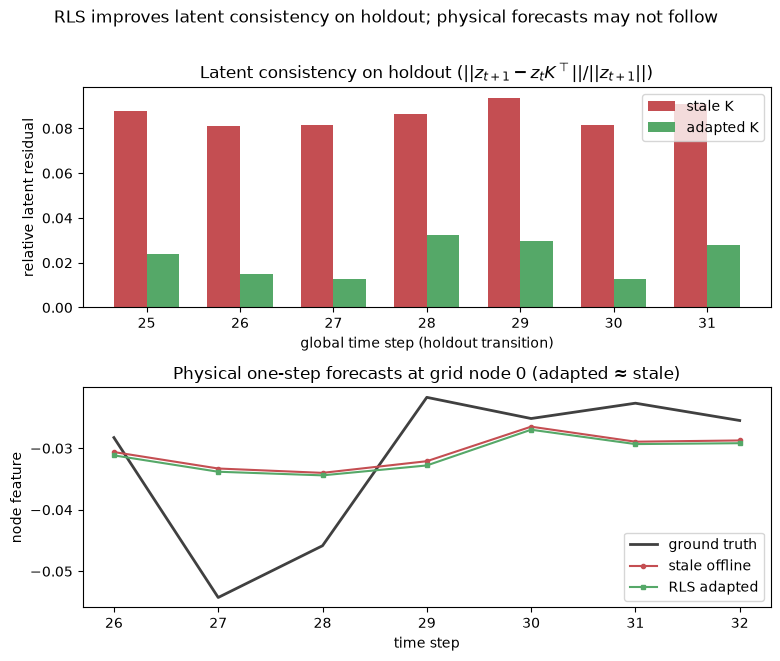

Holdout latent residual — stale: 0.0861, adapted: 0.0221
Node 0 holdout MAE — stale: 0.0081, adapted: 0.0083


In [8]:
NODE = grid_node_index(0, 0, num_cols=NUM_COLS)
HORIZON = min(15, len(holdout) - 1)

# --- Top panel: latent consistency per holdout transition (RLS objective) ---
holdout_latent_stale: list[float] = []
holdout_latent_adapted: list[float] = []
with torch.no_grad():
    for index in range(len(holdout) - 1):
        z_t = adapted_model.encode_latent(holdout[index])
        z_tp1 = adapted_model.encode_latent(holdout[index + 1])
        denom = torch.linalg.norm(z_tp1).clamp_min(1e-8)
        holdout_latent_stale.append(
            (torch.linalg.norm(z_tp1 - z_t @ stale_model.koopman.K.T) / denom).item()
        )
        holdout_latent_adapted.append(
            (torch.linalg.norm(z_tp1 - z_t @ adapted_model.koopman.K.T) / denom).item()
        )

holdout_steps = np.arange(EVAL_START, EVAL_START + len(holdout) - 1)

# --- Bottom panel: physical one-step forecasts at a corner node ---
with torch.no_grad():
    stale_preds: list[float] = []
    adapted_preds: list[float] = []
    truths: list[float] = []
    for offset in range(HORIZON):
        snapshot = holdout[offset]
        truths.append(holdout[offset + 1].x[NODE, 0].item())
        stale_preds.append(stale_model(snapshot)[NODE, 0].item())
        adapted_preds.append(adapted_model(snapshot)[NODE, 0].item())

phys_steps = np.arange(EVAL_START + 1, EVAL_START + 1 + HORIZON)

fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=False)

x = np.arange(len(holdout_latent_stale))
width = 0.35
axes[0].bar(x - width / 2, holdout_latent_stale, width, color="#c44e52", label="stale K")
axes[0].bar(x + width / 2, holdout_latent_adapted, width, color="#55a868", label="adapted K")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(s) for s in holdout_steps])
axes[0].set_xlabel("global time step (holdout transition)")
axes[0].set_ylabel("relative latent residual")
axes[0].set_title(r"Latent consistency on holdout ($||z_{t+1} - z_t K^\top|| / ||z_{t+1}||$)")
axes[0].legend()

axes[1].plot(phys_steps, truths, color="0.25", linewidth=2, label="ground truth")
axes[1].plot(phys_steps, stale_preds, color="#c44e52", marker="o", markersize=3, label="stale offline")
axes[1].plot(phys_steps, adapted_preds, color="#55a868", marker="s", markersize=3, label="RLS adapted")
axes[1].set_xlabel("time step")
axes[1].set_ylabel("node feature")
axes[1].set_title(f"Physical one-step forecasts at grid node {NODE} (adapted ≈ stale)")
axes[1].legend()

fig.suptitle("RLS improves latent consistency on holdout; physical forecasts may not follow", y=1.01)
fig.tight_layout()
plt.show()

stale_mae = float(np.mean(np.abs(np.array(stale_preds) - np.array(truths))))
adapted_mae = float(np.mean(np.abs(np.array(adapted_preds) - np.array(truths))))
print(f"Holdout latent residual — stale: {np.mean(holdout_latent_stale):.4f}, adapted: {np.mean(holdout_latent_adapted):.4f}")
print(f"Node {NODE} holdout MAE — stale: {stale_mae:.4f}, adapted: {adapted_mae:.4f}")


## Summary comparison (holdout)

Side-by-side holdout metrics after the adaptation window. Latent consistency
(the RLS objective) should improve sharply. Physical RMSE may stay flat or
worsen: the frozen GNN never saw the blocked graph during training, so better
latent linear fits need not decode to better physical forecasts.


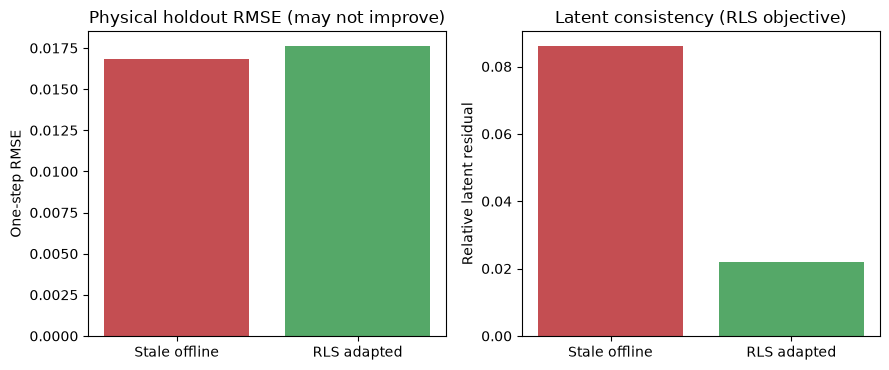

Physical RMSE change (adapted - stale): +0.00078
Latent residual change (adapted - stale): -0.0640


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

axes[0].bar(
    ["Stale offline", "RLS adapted"],
    [stale_rmse, adapted_rmse],
    color=["#c44e52", "#55a868"],
)
axes[0].set_ylabel("One-step RMSE")
axes[0].set_title("Physical holdout RMSE (may not improve)")

axes[1].bar(
    ["Stale offline", "RLS adapted"],
    [np.mean(stale_latent), np.mean(adapted_latent)],
    color=["#c44e52", "#55a868"],
)
axes[1].set_ylabel("Relative latent residual")
axes[1].set_title("Latent consistency (RLS objective)")

fig.tight_layout()
plt.show()

print(
    f"Physical RMSE change (adapted - stale): {adapted_rmse - stale_rmse:+.5f}\n"
    f"Latent residual change (adapted - stale): "
    f"{np.mean(adapted_latent) - np.mean(stale_latent):+.4f}"
)


## Takeaways

- **Topology shocks** are modelled with ``allow_dynamic_topology=True`` and
  per-snapshot ``edge_index`` (horizontal links removed on one grid row).
- **Offline `fit`** learns encoder, decoder, and an initial dense `K` on the
  nominal full-grid segment only.
- **`enable_online_adaptation()` / `adapt_step`** freeze the GNN and update only
  `K` by RLS on encoded pairs — each step uses the snapshot's current topology.
- **Latent consistency improves** (what RLS optimizes). **Physical error may
  stay flat or worsen** on the post-shock holdout: the encoder/decoder never
  saw the blocked graph during training, so latent lifts and decodes are
  misaligned with rewired message-passing neighborhoods. RLS cannot retune
  convolution weights.
- For **known future rewiring**, pass ``future_topologies`` to ``predict``; for
  ongoing drift, combine RLS with periodic encoder/decoder refitting when
  physical mismatch grows. See notebook 06 for end-to-end training on rewiring
  contact networks.

For controlled systems, pass ``control=`` to ``adapt_step``. Continuous-time
models should also pass ``delta_t=``; continuous-mode RLS uses ``logm`` /
``B/Δt`` approximations — see the quickstart online-adaptation section.
